In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
image = np.zeros((7,7), dtype=np.float32)

image[:, :3] = 50
image[:, 3:] = 200
print(image)

[[ 50.  50.  50. 200. 200. 200. 200.]
 [ 50.  50.  50. 200. 200. 200. 200.]
 [ 50.  50.  50. 200. 200. 200. 200.]
 [ 50.  50.  50. 200. 200. 200. 200.]
 [ 50.  50.  50. 200. 200. 200. 200.]
 [ 50.  50.  50. 200. 200. 200. 200.]
 [ 50.  50.  50. 200. 200. 200. 200.]]


In [3]:
kernel = np.array([
  [-1, 0, 1],
  [-1, 0, 1],
  [-1, 0, 1]
], dtype=np.float32)

In [4]:
kernel_h = np.array([
  [-1, -1, -1],
  [0, 0, 0], 
  [1, 1, 1]
], dtype=np.float32)

In [5]:
image_2 = np.zeros((7,7), dtype=np.float32)

image_2[:3, :] = 50
image_2[3:, :] = 200

print(image_2)


[[ 50.  50.  50.  50.  50.  50.  50.]
 [ 50.  50.  50.  50.  50.  50.  50.]
 [ 50.  50.  50.  50.  50.  50.  50.]
 [200. 200. 200. 200. 200. 200. 200.]
 [200. 200. 200. 200. 200. 200. 200.]
 [200. 200. 200. 200. 200. 200. 200.]
 [200. 200. 200. 200. 200. 200. 200.]]


In [6]:
cv2.filter2D(image_2, -1 , kernel_h, borderType=cv2.BORDER_CONSTANT)

array([[ 100.,  150.,  150.,  150.,  150.,  150.,  100.],
       [   0.,    0.,    0.,    0.,    0.,    0.,    0.],
       [ 300.,  450.,  450.,  450.,  450.,  450.,  300.],
       [ 300.,  450.,  450.,  450.,  450.,  450.,  300.],
       [   0.,    0.,    0.,    0.,    0.,    0.,    0.],
       [   0.,    0.,    0.,    0.,    0.,    0.,    0.],
       [-400., -600., -600., -600., -600., -600., -400.]], dtype=float32)

[ WARN:0@0.681] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


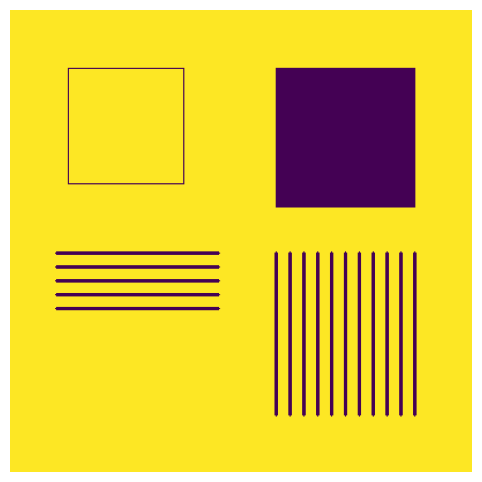

In [7]:
canvas =np.full((400, 400), 255, dtype=np.float32)

cv2.rectangle(canvas, (50,50), (150,150), 0 )
cv2.rectangle(canvas, (230,50), (350,170), 0 , thickness=-1)

for y in range (210, 260, 12):
    cv2.line(canvas,(40, y) , (180, y) ,  0 ,  thickness=2)

for x in range (230, 360, 12):
    cv2.line(canvas,(x, 210) , (x, 350) ,  0 , thickness=2)


cv2.imwrite("d:image.png", canvas)

plt.figure(figsize=(6,6))
plt.imshow(canvas)
plt.axis("off")
plt.show()

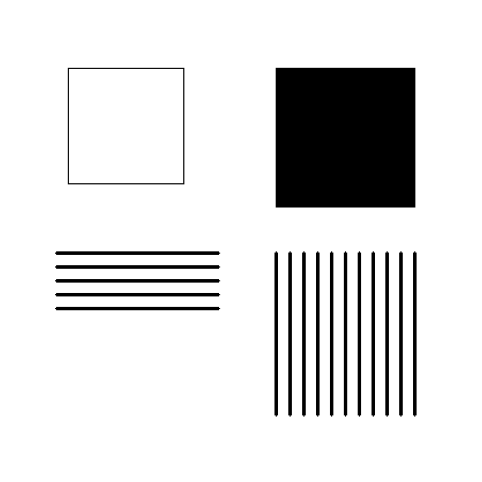

In [8]:
image = cv2.imread("d:image.png")

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.show()

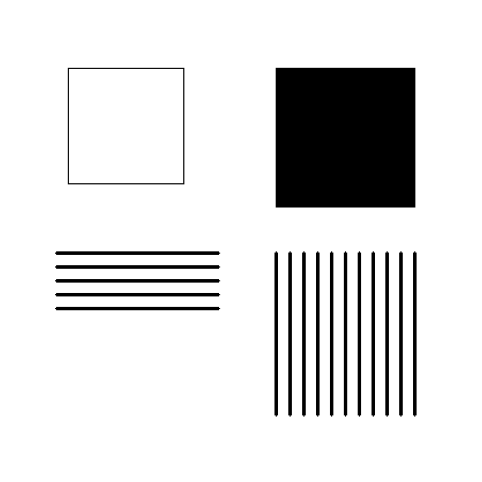

In [9]:
image_bgr = cv2.imread("d:image.png")
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [10]:
image_rgb.shape

(400, 400, 3)

In [11]:
resized = cv2.resize(image_rgb,(224, 224))
resized.shape

(224, 224, 3)

In [12]:
cv2.imwrite("d:r_image.png", resized)

True

In [13]:
image_rgb.shape

(400, 400, 3)

In [14]:
r,g,b = cv2.split(image_rgb)
r.shape , g.shape, b.shape

((400, 400), (400, 400), (400, 400))

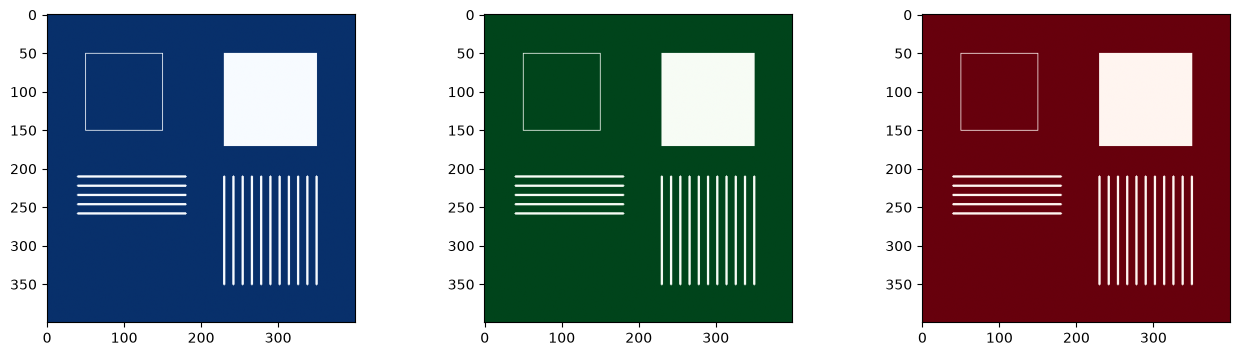

In [15]:
b,g,r = cv2.split(image_bgr)

fig, axes = plt.subplots(1,3, figsize=(16,4))

cmaps = ["Blues", "Greens", "Reds"]
images = [b, g, r]

for ax, img, c in zip(axes, images, cmaps):
    ax.imshow(img, cmap=c)

plt.show()

In [16]:
m = cv2.merge([b,g,r])
m.shape

(400, 400, 3)

In [17]:
image = cv2.imread("d:image.png")
image.shape

(400, 400, 3)

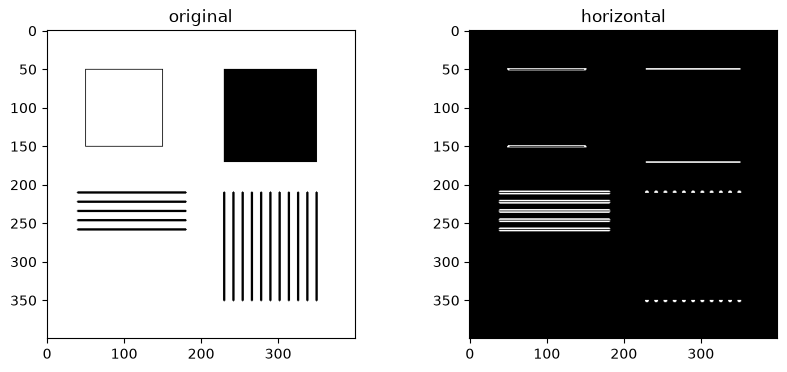

In [18]:
horizontal_kernel = np.array([
  [-1, -1, -1],
  [ 0,  0,  0],
  [ 1,  1,  1]
], dtype=np.float32)


h = cv2.filter2D(image , cv2.CV_64F, horizontal_kernel)
h = cv2.convertScaleAbs(h)


fig, axes = plt.subplots(1,2, figsize=(10,4))
for ax, img, t in zip(axes,[image, h],["original","horizontal"]):     
    ax.imshow(img, cmap='gray')
    ax.set_title(t)
    
plt.show()

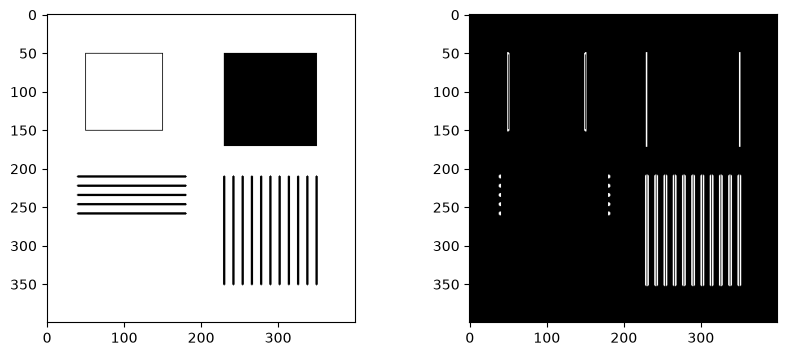

In [19]:
vertical_kernel = np.array([
  [-1,  0, 1],
  [-1,  0, 1],
  [-1,  0, 1]
], dtype=np.float32)

v = cv2.filter2D(image , cv2.CV_64F, vertical_kernel)
v = cv2.convertScaleAbs(v)


fig, axes = plt.subplots(1,2, figsize=(10,4))
for ax, img in zip(axes,[image, v]):     
    ax.imshow(img, cmap='gray')
plt.show()

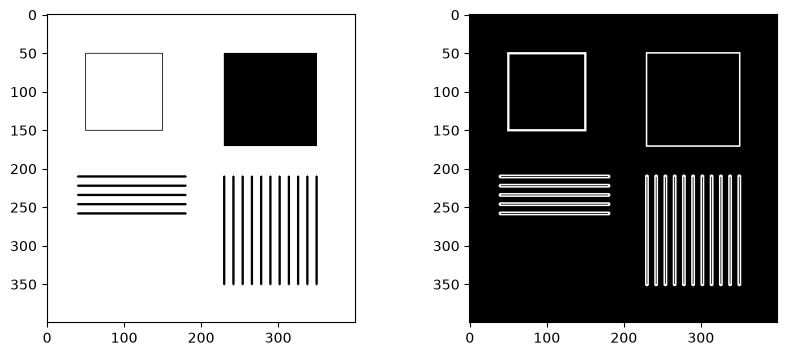

In [20]:
edge_kernel = np.array([
  [-1,  -1, -1],
  [-1,  8, -1],
  [-1,  -1, -1]
], dtype=np.float32)

h = cv2.filter2D(image , cv2.CV_64F, edge_kernel)
h = cv2.convertScaleAbs(h)


fig, axes = plt.subplots(1,2, figsize=(10,4))
for ax, img in zip(axes,[image, h]):     
    ax.imshow(img, cmap='gray')
    
plt.show()

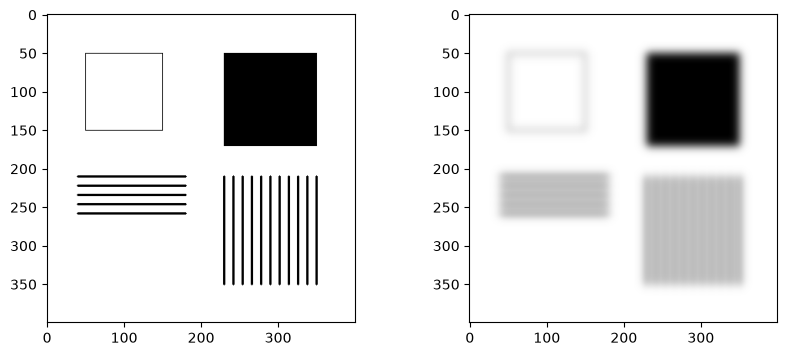

In [21]:
h = cv2.GaussianBlur(image ,(35, 35), 0)

fig, axes = plt.subplots(1,2, figsize=(10,4))
for ax, img in zip(axes,[image, h]):     
    ax.imshow(img, cmap='gray')
    
plt.show()

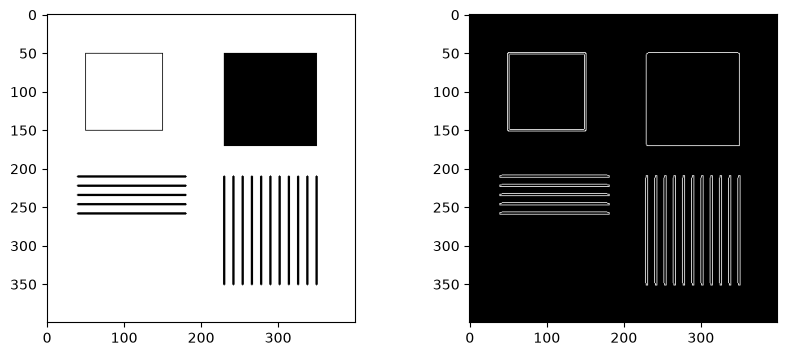

In [22]:
h = cv2.GaussianBlur(image ,(3, 3), 0)
h = cv2.Canny(h, 50 ,100)

fig, axes = plt.subplots(1,2, figsize=(10,4))
for ax, img in zip(axes,[image, h]):     
    ax.imshow(img, cmap='gray')
    
plt.show()

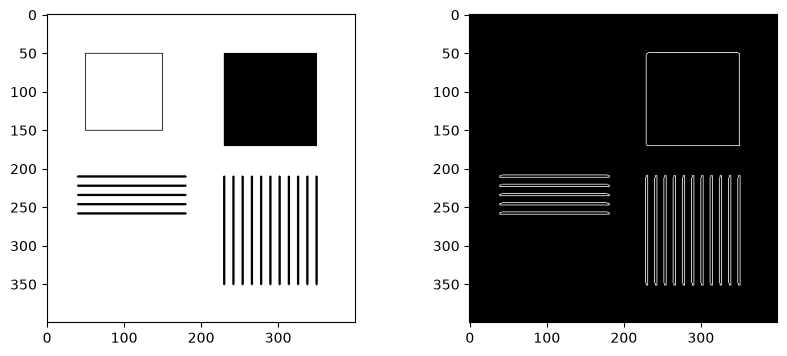

In [23]:
b = cv2.GaussianBlur(image ,(3, 3), 0)

h = cv2.Canny(b, threshold1=300,threshold2=700)

fig, axes = plt.subplots(1,2, figsize=(10,4))

for ax, img in zip(axes,[image, h]):
         
    ax.imshow(img, cmap='gray')
    
plt.show()

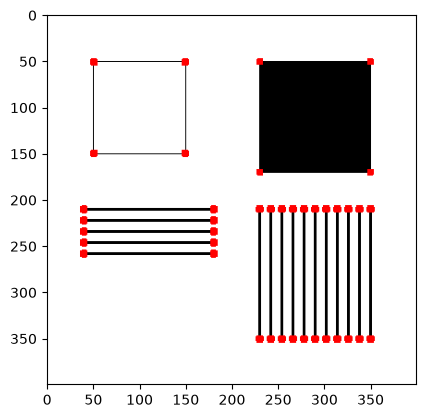

In [24]:
image = cv2.imread("d:image.png", cv2.IMREAD_GRAYSCALE)
image_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
g = np.float32(image)

harris = cv2.cornerHarris(g, blockSize=5, ksize=3, k=0.04)
r =  cv2.dilate(harris, None)
m = r > 0.01 * r.max()
image_color[m] = [0,0,255]

plt.imshow(cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB))
plt.show()